In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0. 데이터 로딩
- ex02에서 저장한 actor별 action pickle 파일들을 불러와서 병합

In [3]:
import pandas as pd
import numpy as np
import ast

In [4]:
import pandas as pd
import numpy as np
import ast

# ex02에서 저장한 pickle 파일 수 (actor 수와 동일)
NUM_ACTORS = 2  # ← cluster_sbert의 고유값 수로 변경

df_list = []
for i in range(1,NUM_ACTORS):
    df_list.append(pd.read_pickle(f"./cluster_df_{i}_action.pkl"))

print(f"{len(df_list)}개 actor 파일 로딩 완료")

FileNotFoundError: [Errno 2] No such file or directory: './cluster_df_1_action.pkl'

In [ ]:
# 하나의 데이터프레임으로 병합
df = pd.concat(df_list, axis=0)
df.reset_index(drop=True, inplace=True)

print("병합 후 shape:", df.shape)
df.head()

In [6]:
df = pd.read_pickle("./cluster_df_2_action__.pkl")

In [7]:
df

,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
83,83,내가만든작품말머리내가 만든 작품현관 콘솔 현관 한쪽 벽면의 조금 들어간 공간을 위한...,"[만들, 작품, 머리, 만들, 작품, 현관, 콘솔, 현관, 한쪽, 벽면, 들어가, ...",만들 작품 머리 만들 작품 현관 콘솔 현관 한쪽 벽면 들어가 공간 위하 현관 콘솔 ...,2,2
86,86,인테리어사진 모음우리집 현관 자랑해봅니다.. 추억속의 공간..철거 전 현관 ai로 ...,"[인테리어, 사진, 모으, 현관, 자랑, 추억, 공간, 철거, 현관, 기존, 지우,...",인테리어 사진 모으 현관 자랑 추억 공간 철거 현관 기존 지우 신축 현관 철거 디디...,2,2
130,130,집소품인테리어커피현관앞 신발장 주변정리 중 어제. 아들넘님 컴터책상으로 사용하던 제...,"[소품, 인테리어, 커피, 현관, 신발장, 주변, 정리, 아들, 책상, 사용, 화장...",소품 인테리어 커피 현관 신발장 주변 정리 아들 책상 사용 화장대 서랍 내보내 현관...,2,1
133,133,로봇청소기 자유스토리드리미 l40s 현관에 자꾸 떨어져요.. 10번방으로 되어있는곳...,"[로봇, 청소기, 자유, 스토리, 현관, 떨어지, 현관, 추락, 걸치, 가상, 세우...",로봇 청소기 자유 스토리 현관 떨어지 현관 추락 걸치 가상 세우 추락 현관 인식 모...,2,1
149,149,일상여행수다현관 탈취제 효과 좋은 거 있나요? 현관에 들어서면 신발 냄새가 심하게 ...,"[일상, 여행, 수다, 현관, 탈취제, 효과, 현관, 들어서, 신발, 냄새, 심하,...",일상 여행 수다 현관 탈취제 효과 현관 들어서 신발 냄새 심하 현관 탈취제 종류 효...,2,5
...,...,...,...,...,...,...
65294,65333,가구 주방가구김포시 장기동신발장 팝니다.,"[가구, 주방, 가구, 김포시, 장기동, 신발장]",가구 주방 가구 김포시 장기동 신발장,2,4
65295,65334,나매신발장좌표문의리플금지쪽지로만신발장 제작 완료 소소한 신발들,"[신발장, 좌표, 리플, 금지, 쪽지, 신발장, 제작, 완료, 신발]",신발장 좌표 리플 금지 쪽지 신발장 제작 완료 신발,2,5
65296,65335,가구 주방가구신발장.수납장.,"[가구, 주방, 가구, 신발장, 수납장]",가구 주방 가구 신발장 수납장,2,2
65297,65336,"가구 침실가구신발장,화장대,침대,엔틱가구,소품 필요하신분","[가구, 침실, 가구, 신발장, 화장대, 침대, 가구, 소품, 필요]",가구 침실 가구 신발장 화장대 침대 가구 소품 필요,2,2


In [8]:
# tokens 컬럼이 문자열인 경우 리스트로 변환
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

# actor 컬럼명 통일 (cluster_sbert → cluster)
if 'cluster_sbert' in df.columns and 'cluster' not in df.columns:
    df = df.rename(columns={'cluster_sbert': 'cluster'})

print("컬럼 목록:", df.columns.tolist())
df.head()

컬럼 목록: ['doc_idx', 'text', 'tokens', 'tokens_str', 'cluster', 'action_cluster']


,doc_idx,text,tokens,tokens_str,cluster,action_cluster
83,83,내가만든작품말머리내가 만든 작품현관 콘솔 현관 한쪽 벽면의 조금 들어간 공간을 위한...,"[만들, 작품, 머리, 만들, 작품, 현관, 콘솔, 현관, 한쪽, 벽면, 들어가, ...",만들 작품 머리 만들 작품 현관 콘솔 현관 한쪽 벽면 들어가 공간 위하 현관 콘솔 ...,2,2
86,86,인테리어사진 모음우리집 현관 자랑해봅니다.. 추억속의 공간..철거 전 현관 ai로 ...,"[인테리어, 사진, 모으, 현관, 자랑, 추억, 공간, 철거, 현관, 기존, 지우,...",인테리어 사진 모으 현관 자랑 추억 공간 철거 현관 기존 지우 신축 현관 철거 디디...,2,2
130,130,집소품인테리어커피현관앞 신발장 주변정리 중 어제. 아들넘님 컴터책상으로 사용하던 제...,"[소품, 인테리어, 커피, 현관, 신발장, 주변, 정리, 아들, 책상, 사용, 화장...",소품 인테리어 커피 현관 신발장 주변 정리 아들 책상 사용 화장대 서랍 내보내 현관...,2,1
133,133,로봇청소기 자유스토리드리미 l40s 현관에 자꾸 떨어져요.. 10번방으로 되어있는곳...,"[로봇, 청소기, 자유, 스토리, 현관, 떨어지, 현관, 추락, 걸치, 가상, 세우...",로봇 청소기 자유 스토리 현관 떨어지 현관 추락 걸치 가상 세우 추락 현관 인식 모...,2,1
149,149,일상여행수다현관 탈취제 효과 좋은 거 있나요? 현관에 들어서면 신발 냄새가 심하게 ...,"[일상, 여행, 수다, 현관, 탈취제, 효과, 현관, 들어서, 신발, 냄새, 심하,...",일상 여행 수다 현관 탈취제 효과 현관 들어서 신발 냄새 심하 현관 탈취제 종류 효...,2,5


### 1. Satisfaction (만족도)
- HuggingFace `monologg/koelectra-base-finetuned-sentiment` 모델로 감성분석
- KNU 감성사전 방식(단어 매칭)과 달리 **문장 전체 문맥**을 이해하여 긍정/부정 분류
- 긍정 확률(0~1)을 감성점수로 사용 → 0~10으로 정규화

#### 1.1 KoELECTRA 모델 로딩
- 모델: `monologg/koelectra-base-finetuned-sentiment`
- 라벨: `positive`(긍정) / `negative`(부정)
- 입력: 원문 텍스트(`text` 컬럼) — 토큰이 아닌 원문 문장 사용
- 512 토큰 초과 시 자동 truncation 처리

In [9]:
!pip install transformers torch -q

In [10]:
from transformers import pipeline

MODEL_NAME = "monologg/koelectra-base-finetuned-sentiment"

# GPU 사용 가능 여부 자동 감지
import torch
device = 0 if torch.cuda.is_available() else -1
print("사용 디바이스:", "GPU" if device == 0 else "CPU")

sentiment_pipeline = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=device
)

# 동작 테스트
print("긍정 테스트:", sentiment_pipeline("오늘 정말 기분이 좋아요!"))
print("부정 테스트:", sentiment_pipeline("너무 힘들고 지쳐서 못하겠어요."))

사용 디바이스: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/441M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-finetuned-sentiment
Key                        | Status     | 
---------------------------+------------+-
classifier.weight          | UNEXPECTED | 
classifier.bias            | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

긍정 테스트: [{'label': 'negative', 'score': 0.5141963362693787}]
부정 테스트: [{'label': 'positive', 'score': 0.5083229541778564}]


#### 1.2 전체 문서 감성분석 (배치 처리)
- `text` 컬럼(원문 문장)을 모델에 입력
- 배치 처리로 속도 향상

In [11]:
from tqdm import tqdm

BATCH_SIZE = 32  # ← GPU 메모리에 따라 조절 (CPU면 16~32 권장)

texts = df['text'].fillna('').tolist()
raw_results = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="감성분석 진행중"):
    batch = texts[i:i + BATCH_SIZE]
    results = sentiment_pipeline(
        batch,
        truncation=True,
        max_length=512
    )
    raw_results.extend(results)

print(f"\n분석 완료: {len(raw_results)}건")
print("결과 샘플:", raw_results[:3])

감성분석 진행중: 100%|██████████| 518/518 [04:33<00:00,  1.89it/s]


분석 완료: 16562건
결과 샘플: [{'label': 'negative', 'score': 0.5109769701957703}, {'label': 'negative', 'score': 0.5022096633911133}, {'label': 'negative', 'score': 0.5054604411125183}]


#### 1.3 긍정 확률을 감성점수로 변환
- `positive` 라벨이면 score 그대로 사용
- `negative` 라벨이면 `1 - score`로 변환
- 결과: 0(완전 부정) ~ 1(완전 긍정)

In [12]:
def extract_positive_score(result):
    """모델 출력에서 긍정 확률 추출"""
    label = result['label'].lower()
    score = result['score']
    if label in ('positive', '1', 'pos'):
        return score
    else:  # negative, 0, neg
        return 1 - score

sentiment_scores = [extract_positive_score(r) for r in raw_results]

df['sentiment_score'] = sentiment_scores

print("감성점수 기초 통계 (긍정 확률 0~1):")
print(df['sentiment_score'].describe())
df[['text', 'cluster', 'action_cluster', 'sentiment_score']].head(10)

감성점수 기초 통계 (긍정 확률 0~1):
count    16562.000000
mean         0.492850
std          0.009192
min          0.456837
25%          0.486910
50%          0.492196
75%          0.498329
max          0.534952
Name: sentiment_score, dtype: float64


,text,cluster,action_cluster,sentiment_score
83,내가만든작품말머리내가 만든 작품현관 콘솔 현관 한쪽 벽면의 조금 들어간 공간을 위한...,2,2,0.489023
86,인테리어사진 모음우리집 현관 자랑해봅니다.. 추억속의 공간..철거 전 현관 ai로 ...,2,2,0.497790
130,집소품인테리어커피현관앞 신발장 주변정리 중 어제. 아들넘님 컴터책상으로 사용하던 제...,2,1,0.494540
133,로봇청소기 자유스토리드리미 l40s 현관에 자꾸 떨어져요.. 10번방으로 되어있는곳...,2,1,0.493090
149,일상여행수다현관 탈취제 효과 좋은 거 있나요? 현관에 들어서면 신발 냄새가 심하게 ...,2,5,0.499321
162,정보게시판심플룸 아기 슈벤치 신발장으로 현관 공간 깔끔하게 정리하기! 이 포스팅은 ...,2,2,0.483810
164,수다방성실회원이상다들 현관청소도 하시죠?? 현관 타일이 베이지색이라 그런가 발자국이...,2,1,0.480043
192,고양이집사의넋두리자현관 방묘문 드디어 첫째를 들이게 된 초보집사인데요!! 저희집 현...,2,3,0.480508
197,운정맘 소곤소곤현관 앞에서 멈칫했네요 저녁쯤 장 보러 나가려는데 현관 앞에 서서 지...,2,1,0.489362
202,쫑알쫑알 게시판로봇청소기 쓰시는 분들 현관쪽 궁금요.. 어제 저도 로봇청소기로보락 ...,2,1,0.502016


#### 1.4 Actor별 Action 감성점수 집계 (평균)

In [13]:
action_sentiments = {}

for actor in sorted(df['cluster'].unique()):
    actor_df = df[df['cluster'] == actor]
    for action in sorted(actor_df['action_cluster'].unique()):
        action_df = actor_df[actor_df['action_cluster'] == action]
        action_sentiment_avg = np.mean(action_df['sentiment_score'])
        key = f"Actor{actor}_Action{action}"
        action_sentiments[key] = action_sentiment_avg
        print(f"  {key}: {action_sentiment_avg:.4f} ({len(action_df)}건)")

print("\n집계 완료")

  Actor2_Action1: 0.4925 (7954건)
  Actor2_Action2: 0.4925 (2521건)
  Actor2_Action3: 0.4910 (1862건)
  Actor2_Action4: 0.4949 (2925건)
  Actor2_Action5: 0.4939 (1300건)

집계 완료


#### 1.5 감성점수 정규화 (0~10 스케일링)

In [14]:
!pip install new_value_analysis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.3 MB/s eta 0:00:00


In [15]:
from new_value_analysis.opportunity_area_analysis import minmax_scale_scores

scaled_scores = minmax_scale_scores(action_sentiments, feature_range=(0, 10))

for key, score in zip(action_sentiments.keys(), scaled_scores):
    action_sentiments[key] = score

print("정규화 후 감성점수 (0~10):")
action_sentiments

정규화 후 감성점수 (0~10):


{'Actor2_Action1': 3.7733,
 'Actor2_Action2': 3.7964,
 'Actor2_Action3': 0.0,
 'Actor2_Action4': 10.0,
 'Actor2_Action5': 7.2808}

In [ ]:
# 1. 감성 점수 정규화 (Min-Max Scaling)
# 분석 모델의 raw score를 사용자가 직관적으로 이해할 수 있는 0~10점 척도로 변환
from new_value_analysis.opportunity_area_analysis import minmax_scale_scores

# 0(매우 부정) ~ 10(매우 긍정) 범위로 점수 재설정
scaled_scores = minmax_scale_scores(action_sentiments, feature_range=(0, 10))

# 2. 만족도(Sentiment)와 중요도(Frequency) 데이터 병합
# 각 액션(Action)별로 계산된 만족도 점수와 언급 빈도(중요도)를 결합
satisfaction_df['importance'] = importance_df['importance']

# 3. 최종 DCX(Digital Customer Experience) 전략 요약 테이블 생성
DCX_summary = satisfaction_df.copy()

In [16]:
# 만족도 데이터프레임 생성 및 저장
satisfaction_df = pd.DataFrame(action_sentiments.items(), columns=['Action', 'satisfaction'])
satisfaction_df.to_pickle('./satisfaction_df.pkl')
print("저장 완료: satisfaction_df.pkl")
satisfaction_df

저장 완료: satisfaction_df.pkl


,Action,satisfaction
0,Actor2_Action1,3.7733
1,Actor2_Action2,3.7964
2,Actor2_Action3,0.0000
3,Actor2_Action4,10.0000
4,Actor2_Action5,7.2808


### 2. Importance (중요도)
- 문서 언급 빈도 기반으로 중요도 측정
- 1~10 범위로 정규화

In [17]:
# 각 문서에 Actor_Action 라벨 부여
actor_action_labels = [
    f"Actor{actor}_Action{action}"
    for actor, action in zip(df['cluster'], df['action_cluster'])
]

s = pd.Series(actor_action_labels)
total_count = s.shape[0]

importances = s.value_counts() / total_count
print("Actor-Action별 언급 비율:")
importances

Actor-Action별 언급 비율:


,count
Actor2_Action1,0.480256
Actor2_Action4,0.176609
Actor2_Action2,0.152216
Actor2_Action3,0.112426
Actor2_Action5,0.078493


In [18]:
scaled_importances = minmax_scale_scores(importances, feature_range=(1, 10))

importance_df = importances.reset_index()
importance_df.columns = ['Action', 'count_ratio']
importance_df['importance'] = scaled_importances

print("정규화 후 중요도 (1~10):")
importance_df

정규화 후 중요도 (1~10):


,Action,count_ratio,importance
0,Actor2_Action1,0.480256,10.0000
1,Actor2_Action4,0.176609,3.1979
2,Actor2_Action2,0.152216,2.6515
3,Actor2_Action3,0.112426,1.7601
4,Actor2_Action5,0.078493,1.0000


### 3. 만족도 + 중요도 병합 및 Opportunity Score
- 공식: `중요도 + max(중요도 - 만족도, 0)`

In [19]:
satisfaction_df = satisfaction_df.set_index('Action')
importance_df = importance_df.set_index('Action')

satisfaction_df['importance'] = importance_df['importance']
DCX_summary = satisfaction_df.copy()

print("DCX Summary:")
DCX_summary

DCX Summary:


,satisfaction,importance
Action,,
Actor2_Action1,3.7733,10.0000
Actor2_Action2,3.7964,2.6515
Actor2_Action3,0.0000,1.7601
Actor2_Action4,10.0000,3.1979
Actor2_Action5,7.2808,1.0000


In [20]:
def opportunity_score(sat, imp):
    """기회점수 = 중요도 + max(중요도 - 만족도, 0)"""
    return imp + max(imp - sat, 0)

DCX_summary['opportunity'] = [
    opportunity_score(s, i)
    for s, i in zip(DCX_summary['satisfaction'], DCX_summary['importance'])
]

DCX_summary.to_csv('./opportunity.csv')
print("저장 완료: opportunity.csv")
DCX_summary

저장 완료: opportunity.csv


,satisfaction,importance,opportunity
Action,,,
Actor2_Action1,3.7733,10.0000,16.2267
Actor2_Action2,3.7964,2.6515,2.6515
Actor2_Action3,0.0000,1.7601,3.5202
Actor2_Action4,10.0000,3.1979,3.1979
Actor2_Action5,7.2808,1.0000,1.0000


### 4. 기회영역 시각화

In [21]:
from new_value_analysis.opportunity_area_analysis import plot_opportunity_area, OpportunityPlotConfig

DCX_summary = DCX_summary.reset_index()
print("컬럼 목록:", DCX_summary.columns.tolist())

컬럼 목록: ['Action', 'satisfaction', 'importance', 'opportunity']


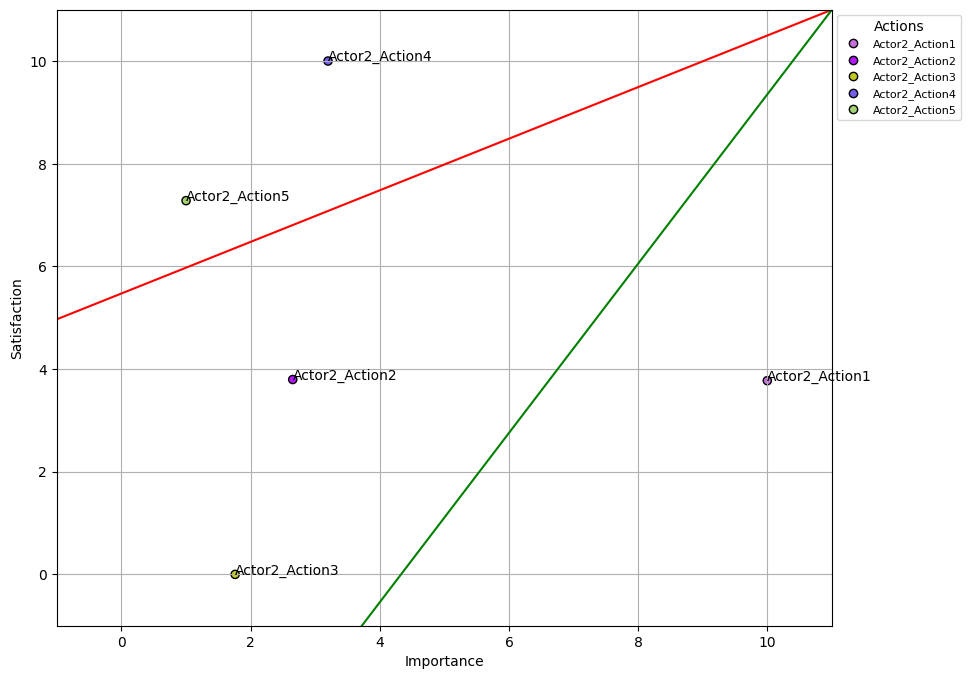

시각화 저장 완료: Opportunity_area.png


In [22]:
cfg = OpportunityPlotConfig(save_path='./Opportunity_area.png',random_seed=42,xlim=(-1,11),ylim=(-1,11))

plot_opportunity_area(DCX_summary.dropna(), cfg)
print("시각화 저장 완료: Opportunity_area.png")